In [85]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

keras.utils.set_random_seed(42)

df= pd.read_csv("heart.csv")
print(df.target.value_counts(normalize=True,dropna=False))

target
1    0.513171
0    0.486829
Name: proportion, dtype: float64


In [86]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [87]:
categorical_var= ['sex', 'cp', 'fbs', 'restecg', 'exang', 'ca', 'thal']
numeric_var= ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'slope']
df=pd.get_dummies(df,columns=categorical_var)
df.head()

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,ca_4,thal_0,thal_1,thal_2,thal_3
0,52,125,212,168,1.0,2,0,False,True,True,...,False,False,False,True,False,False,False,False,False,True
1,53,140,203,155,3.1,0,0,False,True,True,...,True,True,False,False,False,False,False,False,False,True
2,70,145,174,125,2.6,0,0,False,True,True,...,True,True,False,False,False,False,False,False,False,True
3,61,148,203,161,0.0,2,0,False,True,True,...,False,False,True,False,False,False,False,False,False,True
4,62,138,294,106,1.9,1,0,True,False,True,...,False,False,False,False,True,False,False,False,True,False


In [88]:
test_df= df.sample(frac=0.2, random_state=42)
train_df= df.drop(test_df.index)
train_df.shape

(820, 29)

In [89]:
test_df.shape

(205, 29)

In [90]:
mean= train_df[numeric_var].mean()
sd= train_df[numeric_var].std()
train_df[numeric_var]=(train_df[numeric_var]-mean)/sd
test_df[numeric_var]=(test_df[numeric_var]-mean)/sd
train_df = train_df.astype(float)
test_df  = test_df.astype(float)


In [91]:
test_df.head()

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,ca_4,thal_0,thal_1,thal_2,thal_3
527,0.832660,-0.438426,-0.725839,0.595297,-0.911596,1.004651,1.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
359,-0.149131,-0.211391,-0.584904,-1.498242,-0.911596,1.004651,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
447,0.069045,1.604886,0.884844,-0.189780,-0.210533,-0.639688,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
31,-0.476395,-0.665461,-0.021165,0.551682,0.052366,1.004651,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
621,-0.694571,-0.097874,0.220438,0.028297,-0.911596,1.004651,0.0,0.0,1.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [92]:
train_df.head()

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,ca_4,thal_0,thal_1,thal_2,thal_3
0,-0.258219,-0.381667,-0.665438,0.813374,-0.035267,1.004651,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.149131,0.469713,-0.846640,0.246374,1.805024,-2.284027,0.0,0.0,1.0,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.705364,0.753506,-1.430512,-1.062088,1.366860,-2.284027,0.0,0.0,1.0,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.832660,0.356195,0.985512,-1.890781,0.753429,-0.639688,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
5,0.396308,-1.800634,0.059369,-1.192934,-0.035267,-0.639688,1.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [93]:
y_train = train_df["target"].to_numpy()
X_train = train_df.drop(columns=["target"]).to_numpy()

y_test  = test_df["target"].to_numpy()
X_test  = test_df.drop(columns=["target"]).to_numpy()


In [94]:
print(X_train.shape, X_train.dtype)
print(y_train.shape, y_train.dtype)


(820, 28) float64
(820,) float64


In [95]:
num_columns= X_train.shape[1]

input= keras.Input(shape=(num_columns,))

h=keras.layers.Dense(16,activation='relu', name="hidden")(input)

output= keras.layers.Dense(1,activation="sigmoid", name='output')(h)

model= keras.Model(input,output)
model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 28)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ (None, 16)             │           464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 481 (1.88 KB)

 Trainable params: 481 (1.88 KB)

 Non-trainable params: 0 (0.00 B)

In [96]:
keras.utils.plot_model(model,show_shapes=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [97]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(X_train,              
                    y_train,            
                    epochs=300,           
                    batch_size=32,        
                    verbose=1,            
                    validation_split=0.2)  

Epoch 1/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.6555 - loss: 0.6192 - val_accuracy: 0.6585 - val_loss: 0.6000
Epoch 2/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7515 - loss: 0.5514 - val_accuracy: 0.7256 - val_loss: 0.5467
Epoch 3/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7988 - loss: 0.4980 - val_accuracy: 0.7683 - val_loss: 0.5049
Epoch 4/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8399 - loss: 0.4542 - val_accuracy: 0.7744 - val_loss: 0.4719
Epoch 5/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8491 - loss: 0.4185 - val_accuracy: 0.8110 - val_loss: 0.4467
Epoch 6/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8796 - loss: 0.3902 - val_accuracy: 0.8049 - val_loss: 0.4279
Epoch 7/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8780 - loss: 0.3679 - val_accuracy: 0.7988 - val_loss: 0.4140
Epoch 8/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8720 - loss: 0.3504 - val_accuracy: 0.8110

In [98]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

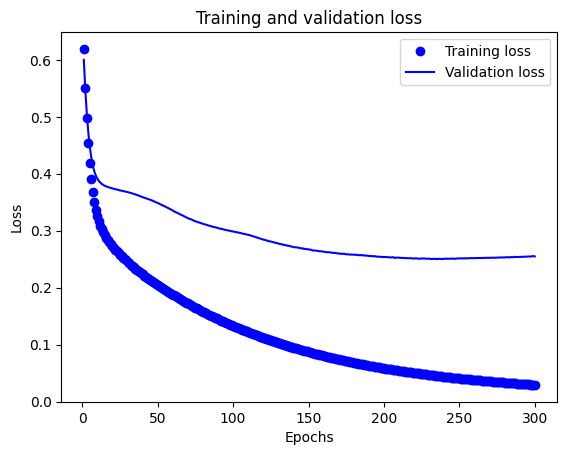

In [99]:
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "bo", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

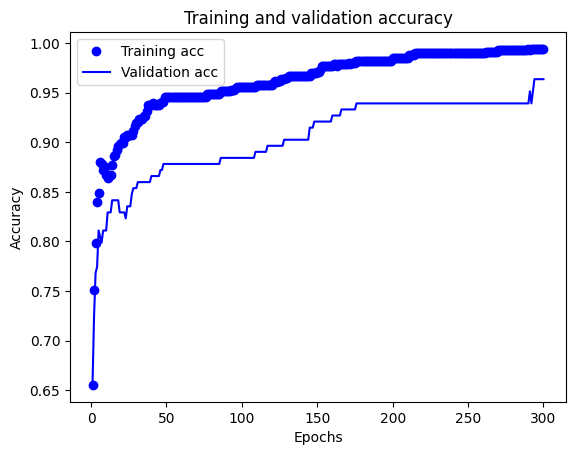

In [100]:
plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
plt.plot(epochs, acc, "bo", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [101]:
model.evaluate(X_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9463 - loss: 0.3036 


[0.3035784959793091, 0.9463414549827576]